In [2]:
# 数值计算
import numpy as np
# 读取,清洗数据
import pandas as pd
# 画图
import matplotlib.pyplot as plt
# 更高级一点的画图
import seaborn as sns
# 让图显示在notebook
%matplotlib inline

屏蔽警告信息

In [3]:
import warnings

warnings.filterwarnings('ignore')

读数据

In [4]:
data = 'data\car_evaluation.csv'

# csv文件没有表头,不要把第一行当做列名
# pd.read_csv(data) == pd.read_csv(data, header=0)  ---> 把第一行当做列名
df = pd.read_csv(data, header=None)

In [5]:
df.shape

(1728, 7)

In [6]:
df.head()

,0,1,2,3,4,5,6
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


列名重名名

In [7]:
col_names = ['buying', 'maint', 'doors','persons', 'lug_boot', 'safety', 'class']
df.columns = col_names

col_names

['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']

In [8]:
df.head()

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


查看数据,此案例不许要进行数据清洗,可以通过`df.info`,查看当前数据是否有异常,由此避免`rubbish` `in` `rubbish` `out`

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   buying    1728 non-null   str  
 1   maint     1728 non-null   str  
 2   doors     1728 non-null   str  
 3   persons   1728 non-null   str  
 4   lug_boot  1728 non-null   str  
 5   safety    1728 non-null   str  
 6   class     1728 non-null   str  
dtypes: str(7)
memory usage: 94.6 KB


用来查看各个`value`的分布,查看每个特征类别分布

In [10]:
col_names = ['buying', 'maint', 'doors','persons', 'lug_boot', 'safety', 'class']

for col in col_names:
  print(df[col].value_counts())

buying
vhigh    432
high     432
med      432
low      432
Name: count, dtype: int64
maint
vhigh    432
high     432
med      432
low      432
Name: count, dtype: int64
doors
2        432
3        432
4        432
5more    432
Name: count, dtype: int64
persons
2       576
4       576
more    576
Name: count, dtype: int64
lug_boot
small    576
med      576
big      576
Name: count, dtype: int64
safety
low     576
med     576
high    576
Name: count, dtype: int64
class
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64


其中`class`是预测值`y`,在此进行额外查看,大致分布

In [11]:
df['class'].value_counts()

class
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64

查看是否有空值,不过有前面的那个`df.info`大致也可以看到

In [12]:
df.isnull().sum()

buying      0
maint       0
doors       0
persons     0
lug_boot    0
safety      0
class       0
dtype: int64

声明特征向量和目标向量,其中`y`是目标向量,其余都是特征向量

In [13]:
# df.drop['class']是在axis=1的这一行里面排除class这一类,其他都需要有


# axis=0: 竖着走,上下走
# axis=1: 横着走, 左右走
X = df.drop(['class'], axis=1)

y = df['class']

数据进行切割

In [14]:
# 导入函数
from sklearn.model_selection import train_test_split

# 拿33%的数据做测试集,其余做训练集,random_state作为随机种子,这样防止每次进行切分的时候都是不一样的数据,这样明显是不可靠的
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state = 42)

In [15]:
# 查看数据类型和维度,是否切分正确
X_train.shape, X_test.shape

((1157, 6), (571, 6))

首先查看数据类型

In [16]:
X_train.dtypes

buying      str
maint       str
doors       str
persons     str
lug_boot    str
safety      str
dtype: object

In [17]:
X_train.head()

,buying,maint,doors,persons,lug_boot,safety
48,vhigh,vhigh,3,more,med,low
468,high,vhigh,3,4,small,low
155,vhigh,high,3,more,small,high
1721,low,low,5more,more,small,high
1208,med,low,2,more,small,high


把字符串转换成模型能处理的数字

In [18]:
import category_encoders as ce

In [19]:
encoder = ce.OrdinalEncoder(cols=['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety'])

# 先在训练集上学编码规则,再把训练集转换成数值,fit_transformer是训练集
X_train = encoder.fit_transform(X_train)


# 不要重新学习规则,只使用训练集学到的规则,去转换测试集,transformer默认是指测试集
X_test = encoder.transform(X_test)

In [20]:
X_train.head()

,buying,maint,doors,persons,lug_boot,safety
48,1,1,1,1,1,1
468,2,1,1,2,2,1
155,1,2,1,1,2,2
1721,3,3,2,1,2,2
1208,4,3,3,1,2,2


In [21]:
X_test.head()

,buying,maint,doors,persons,lug_boot,safety
599,2,2,4,3,1,2
1201,4,3,3,2,1,3
628,2,2,2,3,3,3
1498,3,2,2,2,1,3
1263,4,3,4,1,1,1


进行训练

In [22]:
# 导入随机森林分类器
from sklearn.ensemble import RandomForestClassifier



# 创建分类器对象, random_state=0和前面的那个randm_state是同样的道理,保证是可复现的(进行切分之后的数据是一样)

rfc = RandomForestClassifier(random_state=0)



# 训练模型

rfc.fit(X_train, y_train)



# 开始进行预测

y_pred = rfc.predict(X_test)



# 导入准确评估函数,进行预测

from sklearn.metrics import accuracy_score

# 打印答案
print('Model accuracy score with 10 decision-trees : {0:0.4f}'. format(accuracy_score(y_test, y_pred)))

Model accuracy score with 10 decision-trees : 0.9457


In [23]:
rfc_100 = RandomForestClassifier(n_estimators=100, random_state=0)



# 训练模型

rfc_100.fit(X_train, y_train)



# 预测

y_pred_100 = rfc_100.predict(X_test)



# 正确率 

print('Model accuracy score with 100 decision-trees : {0:0.4f}'. format(accuracy_score(y_test, y_pred_100)))

Model accuracy score with 100 decision-trees : 0.9457


In [24]:
clf = RandomForestClassifier(n_estimators=100, random_state=0)



# 训练

clf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


把随机森林学出来的"特征重要性"取出来,并配上列名,并按高到低排序

In [ ]:
# index=X_train.columns 把列名作为这个Series的索引,若删去之后就会显示0,1,2,3,4
# ascending=True:从小到大
feature_scores = pd.Series(clf.feature_importances_, index=X_train.columns).sort_values(ascending=False)

feature_scores

safety      0.314043
persons     0.242431
buying      0.177629
maint       0.157824
lug_boot    0.108074
dtype: float64

开始画图

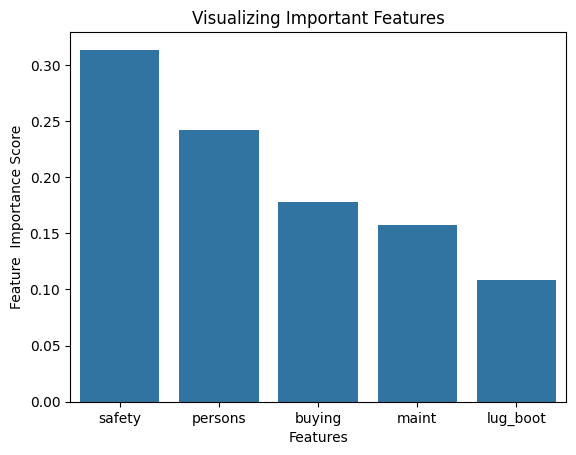

In [ ]:
# 将刚才的feature_scores作为变量进行展示
# 由于这个index是放在y这里,所以在y轴上面是进行展示这个index,index顾名思义,就是表名
sns.barplot(x=feature_scores.index, y=feature_scores)



# 画轴

# x轴
plt.xlabel('Features')

# y轴
plt.ylabel('Feature  Importance Score')



# 增加表名

plt.title("Visualizing Important Features")



# z展示图表
plt.show()

由结果分析可得,在概率里面并有`doors`这个选项,因此,这是一个毫无关系的变量,以下开始删除不重要的特征,重建模型

In [27]:
X = df.drop(['class', 'doors'], axis=1)

y = df['class']

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state = 42)

In [29]:
encoder = ce.OrdinalEncoder(cols=['buying', 'maint', 'persons', 'lug_boot', 'safety'])


X_train = encoder.fit_transform(X_train)

X_test = encoder.transform(X_test)

In [ ]:
clf = RandomForestClassifier(random_state=0)



# 训练模型

clf.fit(X_train, y_train)


# 预测模型
y_pred = clf.predict(X_test)



# 打印正确率

print('Model accuracy score with doors variable removed : {0:0.4f}'. format(accuracy_score(y_test, y_pred)))

Model accuracy score with doors variable removed : 0.9264


In [ ]:
# 导入混淆矩阵函数,查看模型到底是错在哪里
from sklearn.metrics import confusion_matrix

# 拿真实结果和预测结果做交叉统计,生成矩阵
cm = confusion_matrix(y_test, y_pred)

# 对角线上的数是预测对的,非对角线上的数预测错的
print('Confusion matrix\n\n', cm)

Confusion matrix

 [[104  12  10   3]
 [  0  18   0   2]
 [ 10   0 387   0]
 [  3   2   0  20]]


还是看不懂的话,可以看下面这个图

![图像演示](photo/confusion.png)

In [ ]:
# 进行完整的数据分析
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         acc       0.89      0.81      0.85       129
        good       0.56      0.90      0.69        20
       unacc       0.97      0.97      0.97       397
       vgood       0.80      0.80      0.80        25

    accuracy                           0.93       571
   macro avg       0.81      0.87      0.83       571
weighted avg       0.93      0.93      0.93       571

